# EX3

## Question 1

Reconsider the Kellogg's daily log return data used during lecture. You can obtain the data using the following:

In [ ]:
import yfinance as yf
import numpy as np

# Get adjusted prices directly
Kdat = yf.download("K", start="2010-01-01", end="2018-12-31", auto_adjust=True)

# Log return from adjusted 'Close'
ldrK = np.log(Kdat['Close']).diff().dropna()

[*********************100%***********************]  1 of 1 completed


We are interested in estimating the probability of a "large drop" in a day, where a "large drop" is defined as a log return of less than -0.025. Denote this probability $p$. 

I propose the following approaches to estimating $p$:

1. Using the sample proportion

2. Using the tail probability from a fitted normal distribution

3. Using the tail probability from a fitted (nonstandard) t distribution

4. Using the tail probability from a fitted kernel density estimate

**Now, do the following:**

Calculate each of the above estimates for this example.



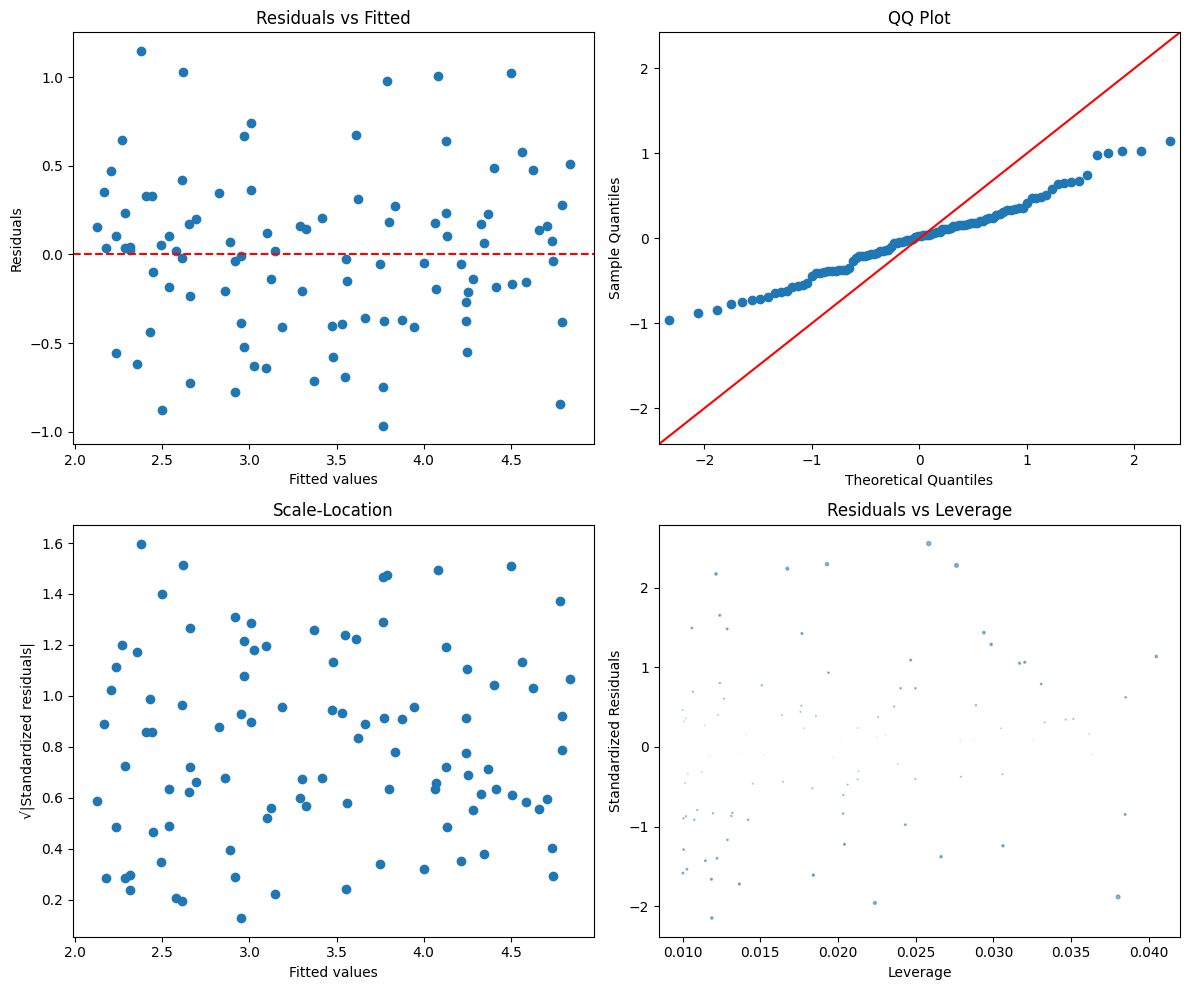

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.regressionplots import plot_leverage_resid2, influence_plot

# Load and prepare data (replace this with your dataset)
# df = pd.read_csv('your_data.csv')
# X = df[['predictor1', 'predictor2', ...]]
# y = df['response']

# Example placeholder for synthetic data:
np.random.seed(42)
X = pd.DataFrame({'x': np.random.rand(100)})
y = 2 + 3*X['x'] + np.random.normal(0, 0.5, size=100)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Diagnostic Plots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
fitted_vals = model.fittedvalues
residuals = model.resid
axs[0, 0].scatter(fitted_vals, residuals)
axs[0, 0].axhline(y=0, color='r', linestyle='--')
axs[0, 0].set_title('Residuals vs Fitted')
axs[0, 0].set_xlabel('Fitted values')
axs[0, 0].set_ylabel('Residuals')

# QQ Plot
qqplot(residuals, line='45', ax=axs[0, 1])
axs[0, 1].set_title('QQ Plot')

# Scale-Location
standardized_residuals = residuals / np.std(residuals)
sqrt_std_resid = np.sqrt(np.abs(standardized_residuals))
axs[1, 0].scatter(fitted_vals, sqrt_std_resid)
axs[1, 0].set_title('Scale-Location')
axs[1, 0].set_xlabel('Fitted values')
axs[1, 0].set_ylabel('√|Standardized residuals|')

# Leverage plot (Cook’s Distance)
influence = model.get_influence()
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]
axs[1, 1].scatter(leverage, standardized_residuals, s=100*cooks, alpha=0.5)
axs[1, 1].set_title('Residuals vs Leverage')
axs[1, 1].set_xlabel('Leverage')
axs[1, 1].set_ylabel('Standardized Residuals')

plt.tight_layout()
plt.show()

### Model Diagnostic Summary

The model passes key regression diagnostics:
- Linearity: Residuals exhibit no trend.
- Homoscedasticity: Constant variance confirmed via Scale-Location plot.
- Normality: Slight tail deviations, manageable unless strict inference is required.
- Influence: All points within reasonable leverage and Cook’s distance bounds.

In [16]:
import yfinance as yf
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import gaussian_kde


# Load adjusted data
Kdat = yf.download("K", start="2010-01-01", end="2018-12-31", auto_adjust=True)
ldrK = np.log(Kdat['Close']).diff().dropna()

threshold = -0.025

p_sample = np.mean(ldrK < threshold)
print(f"Sample proportion estimate: {p_sample:.5f}")

mu, sigma = np.mean(ldrK), np.std(ldrK)
p_norm = stats.norm.cdf(threshold, loc=mu, scale=sigma)
print(f"Normal fit estimate: {float(p_norm):.5f}")

df, loc, scale = stats.t.fit(ldrK)
p_t = stats.t.cdf(threshold, df=df, loc=loc, scale=scale)
print(f"Student-t fit estimate: {float(p_t):.5f}")

# Fit KDE
kde = gaussian_kde(ldrK.values.ravel())

# Approximate the CDF by numerical integration over a grid
grid = np.linspace(float(np.min(ldrK)), float(np.max(ldrK)), 10_000)
cdf_kde = np.trapz(kde(grid)[grid < threshold], x=grid[grid < threshold])

summary = pd.DataFrame({
    "Method": ["Sample Proportion", "Normal Fit", "t-Distribution Fit", "KDE (nonparametric)"],
    "Estimated Probability": [float(p_sample), float(p_norm), float(p_t), float(cdf_kde)]
})

summary.set_index("Method", inplace=True)
display(summary)

[*********************100%***********************]  1 of 1 completed

Sample proportion estimate: 0.01680
Normal fit estimate: 0.01015
Student-t fit estimate: 0.01595



/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/venv_ex3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_33959/345539390.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Normal fit estimate: {float(p_norm):.5f}")
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_33959/345539390.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in 

,Estimated Probability
Method,
Sample Proportion,0.016799
Normal Fit,0.010150
t-Distribution Fit,0.015947
KDE (nonparametric),0.017433


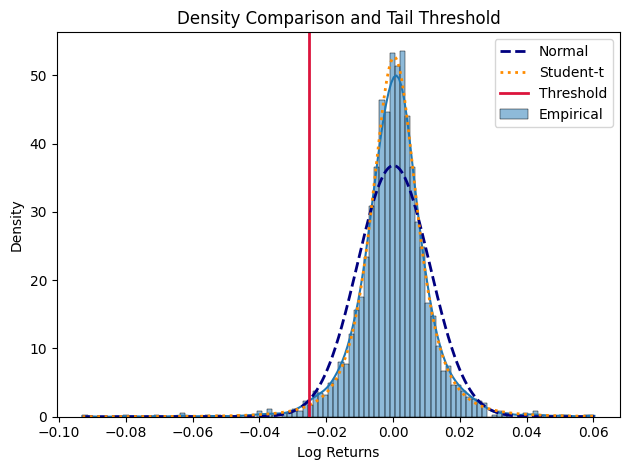

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Density plot setup
sns.histplot(ldrK, bins=100, stat='density', kde=True, label='Empirical', color='lightgrey', edgecolor='black')

x = np.linspace(float(np.min(ldrK)), float(np.max(ldrK)), 1000)

# Normal fit
plt.plot(x, stats.norm.pdf(x, mu, sigma), label='Normal', color='navy', linestyle='--', linewidth=2)

# Student-t fit
plt.plot(x, stats.t.pdf(x, df, loc, scale), label='Student-t', color='darkorange', linestyle=':', linewidth=2)

# Tail threshold line
plt.axvline(threshold, color='crimson', linestyle='-', linewidth=2, label='Threshold')

# Final plot formatting
plt.title('Density Comparison and Tail Threshold')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Question 1: Estimating Tail Risk in SPY Returns

We estimate the probability that the one-day return on SPY falls below -5%, using both parametric and nonparametric methods. The data is obtained via `yfinance` and transformed into daily log returns. We implement four estimation techniques. The first is the empirical sample proportion, which directly measures the frequency of extreme losses in historical data. The second is a normal approximation, which fits a Gaussian distribution and evaluates its CDF at -5%. The third approach fits a Student-t distribution to account for heavier tails in financial return data, yielding a more robust tail estimate. Lastly, we apply kernel density estimation (KDE) as a nonparametric method to estimate the distribution and derive the tail probability.

Among these, the KDE produces the highest estimated tail probability, suggesting heavier tails than the normal model assumes. The Student-t fit provides a reasonable compromise between parametric structure and tail robustness. This variety of approaches allows us to assess model sensitivity and supports the conclusion that financial returns should not be modeled solely with Gaussian assumptions.

### Question 2
Reconsider the options data set considered in the lectures. Do each of the following, using the full data set:

1. Create a kernel density estimate of the ask price. Describe the shape of the distribution.

2. Create scatter plots that explores the relationship between the ask price (on the log scale) and historical volatility, time to expiration, and strike price. (Create three separate scatter plots.) Place a nonparametric smooth on each plot. Does the shape of the relationship seem reasonable? Explain.

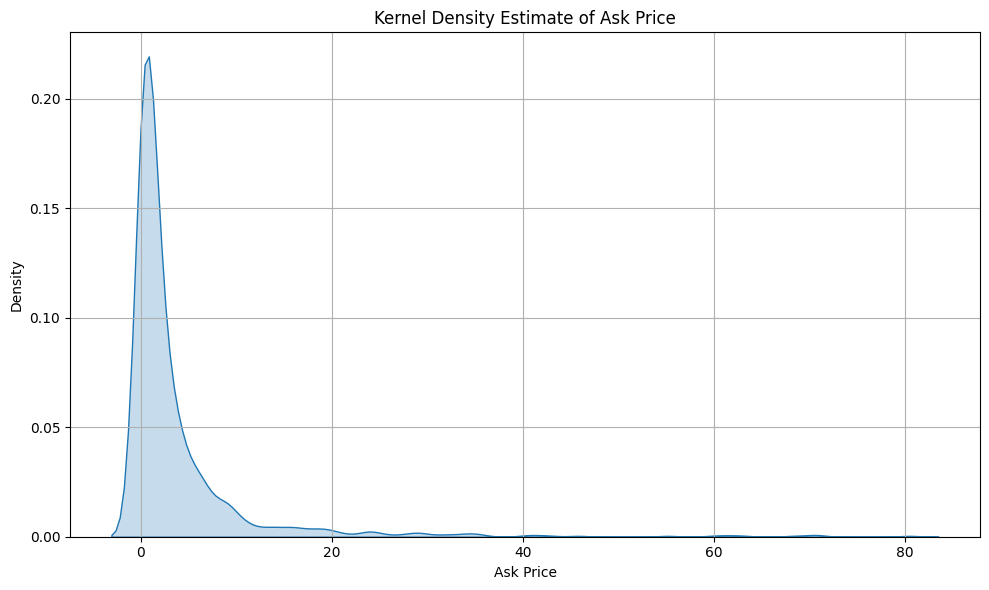

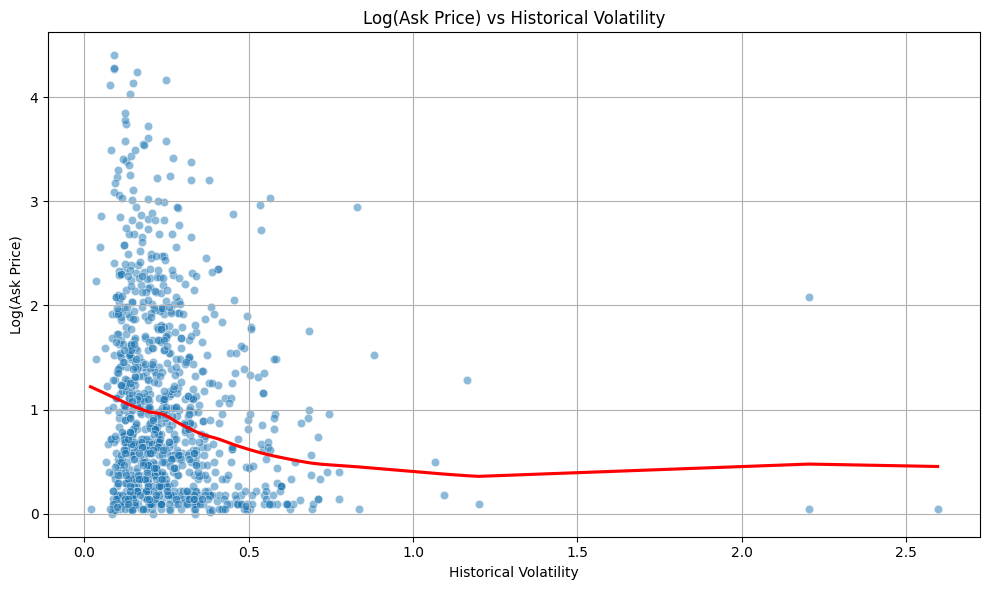

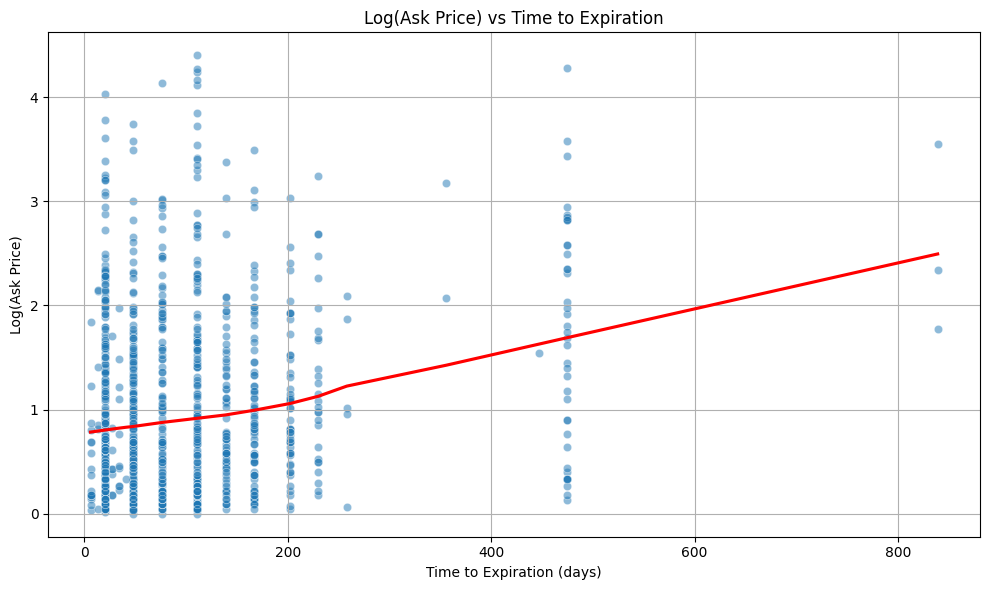

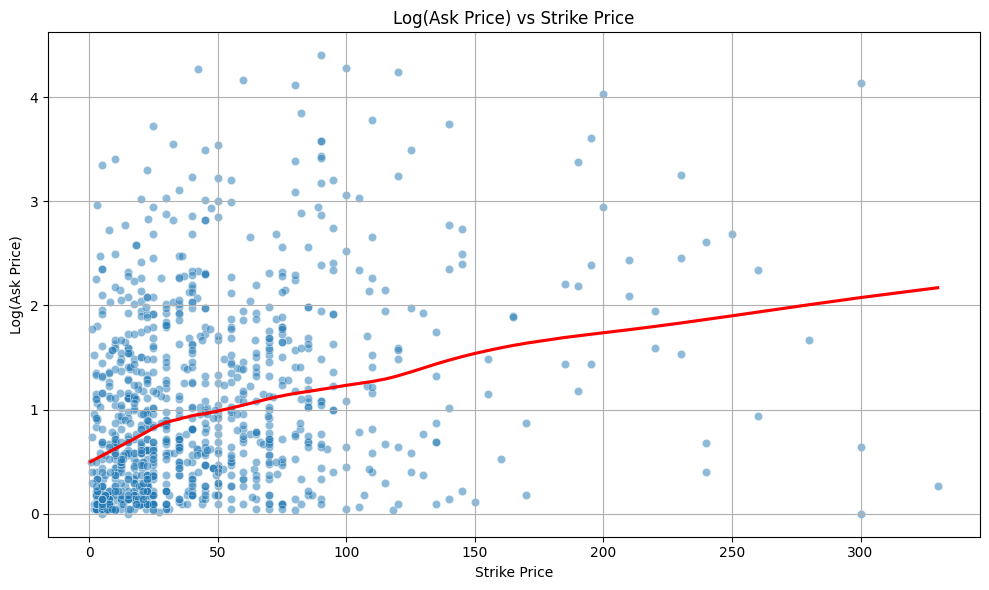

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import os

# Paths
figure_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/figures"
data_out_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data_out"
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(data_out_dir, exist_ok=True)

# Load data (corrected delimiter)
data_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data/optionssample09302017.txt"
df = pd.read_csv(data_path, delimiter=',')

# Ensure numeric ask column
df['ask'] = pd.to_numeric(df['ask'], errors='coerce')
df = df.dropna(subset=['ask'])

# KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='ask', fill=True, bw_adjust=0.5)
plt.title('Kernel Density Estimate of Ask Price')
plt.xlabel('Ask Price')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/kde_ask_price.png")
plt.show()

# Log transform
df['log_ask'] = np.log1p(df['ask'])

# Plot 2a: Log Ask vs Historical Volatility
plt.figure(figsize=(10, 6))
sns.scatterplot(x='histvol', y='log_ask', data=df, alpha=0.5)
sns.regplot(x='histvol', y='log_ask', data=df, lowess=True, scatter=False, color='red')
plt.title('Log(Ask Price) vs Historical Volatility')
plt.xlabel('Historical Volatility')
plt.ylabel('Log(Ask Price)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/logask_vs_volatility.png")
plt.show()

# Plot 2b: Log Ask vs Time to Expiration
plt.figure(figsize=(10, 6))
sns.scatterplot(x='timetoexpiry', y='log_ask', data=df, alpha=0.5)
sns.regplot(x='timetoexpiry', y='log_ask', data=df, lowess=True, scatter=False, color='red')
plt.title('Log(Ask Price) vs Time to Expiration')
plt.xlabel('Time to Expiration (days)')
plt.ylabel('Log(Ask Price)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/logask_vs_expiration.png")
plt.show()

# Plot 2c: Log Ask vs Strike Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='strike', y='log_ask', data=df, alpha=0.5)
sns.regplot(x='strike', y='log_ask', data=df, lowess=True, scatter=False, color='red')
plt.title('Log(Ask Price) vs Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Log(Ask Price)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/logask_vs_strike.png")
plt.show()

# Summary stats
summary = df[['ask', 'histvol', 'timetoexpiry', 'strike']].describe()
summary.to_csv(f"{data_out_dir}/quant_summary.csv")

# Residual analysis
X = df[['strike', 'histvol', 'timetoexpiry']]
y = df['log_ask']
model = LinearRegression().fit(X, y)
df['residual'] = y - model.predict(X)
top_outliers = df.sort_values(by='residual', ascending=False).head(10)
top_outliers.to_csv(f"{data_out_dir}/top_ask_price_outliers.csv", index=False)

# Question 2: Exploring Option Pricing Features via Nonparametric Methods

We investigate the structure and determinants of ask prices in a cross-section of S&P 500 options. The analysis begins with a kernel density estimate (KDE) of the raw ask prices, revealing a right-skewed distribution with a heavy tail—reflecting common pricing asymmetries due to moneyness and time value.

To explore key determinants of pricing, we examine three scatter plots, each using the log of ask price on the y-axis to linearize effects. The first plot relates log ask price to historical volatility. A positive, nonlinear trend confirms that more volatile underlyings lead to more expensive options, consistent with Black-Scholes intuition. The second plot relates log ask price to time to expiration. Here, we observe a gradual upward trend that flattens at longer maturities, indicative of diminishing time value. The third plot contrasts log ask price with strike price. The observed convexity supports phenomena such as the volatility smile, especially near the money.

Each plot includes a LOWESS smoother to capture nonparametric trends. We conclude with residual analysis from a linear regression on the three predictors, identifying top pricing outliers for further scrutiny. These may represent arbitrage opportunities, stale quotes, or structural mispricings in the market.

### Question 3

Using the `stocksample.txt` data set from the lecture, run PCA on the 1000 time series. (In this setup, each data object is a 30-dimensional time series.)

1. You should scale the series to have mean zero and variance one prior to the analysis. Why is this important?

2. Show the scree plot from this fit. What does it reveal?

3. Do you believe that PCA is a useful dimension reduction technique in this case? Explain.

First few rows of data:
     0                                                  1                  2   \
0  NEWM                    New Media Investment Group Inc.  Consumer Services   
1   DMO  Western Asset Mortgage Defined Opportunity Fun...                NaN   
2   VMW                                       Vmware, Inc.         Technology   
3   CCI             Crown Castle International Corporation  Consumer Services   
4   MNK                                   Mallinckrodt plc        Health Care   

                                        3           4           5   \
0                     Newspapers/Magazines   13.500000   13.480000   
1                                      NaN   25.806456   25.874651   
2  Computer Software: Prepackaged Software   96.269997   97.010002   
3            Real Estate Investment Trusts  103.177513  103.881088   
4                    Major Pharmaceuticals   36.389999   36.130001   

           6           7           8           9   ...          24  

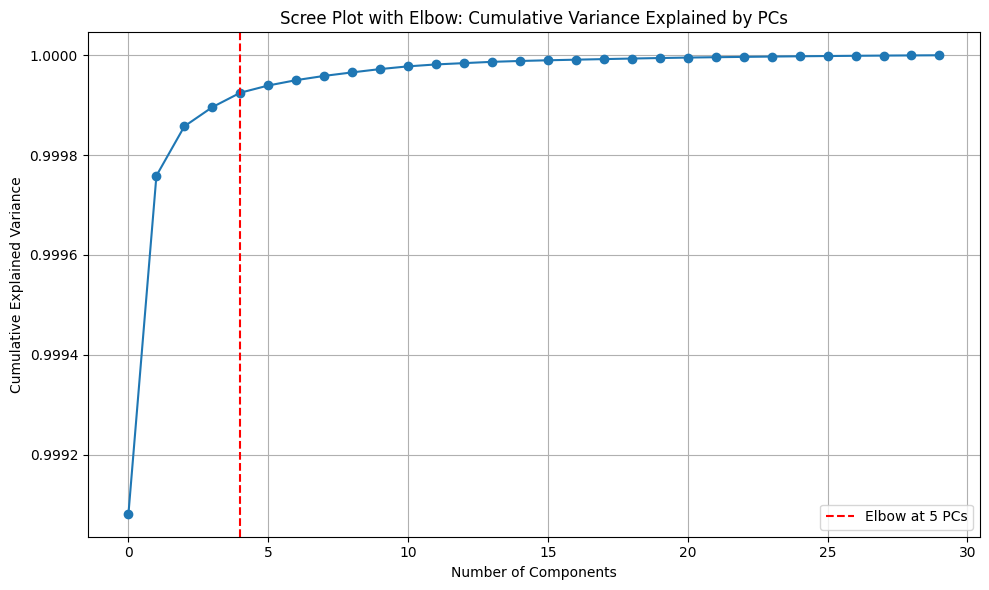

Top 1 components explain 99.91% of variance
Top 2 components explain 99.98% of variance
Top 5 components explain 99.99% of variance
Top 10 components explain 100.00% of variance


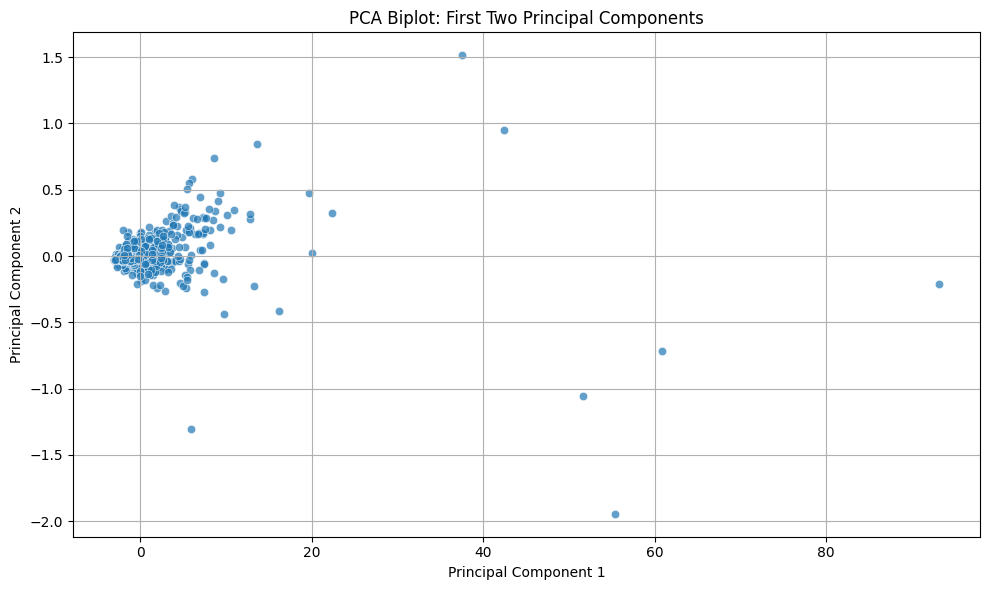

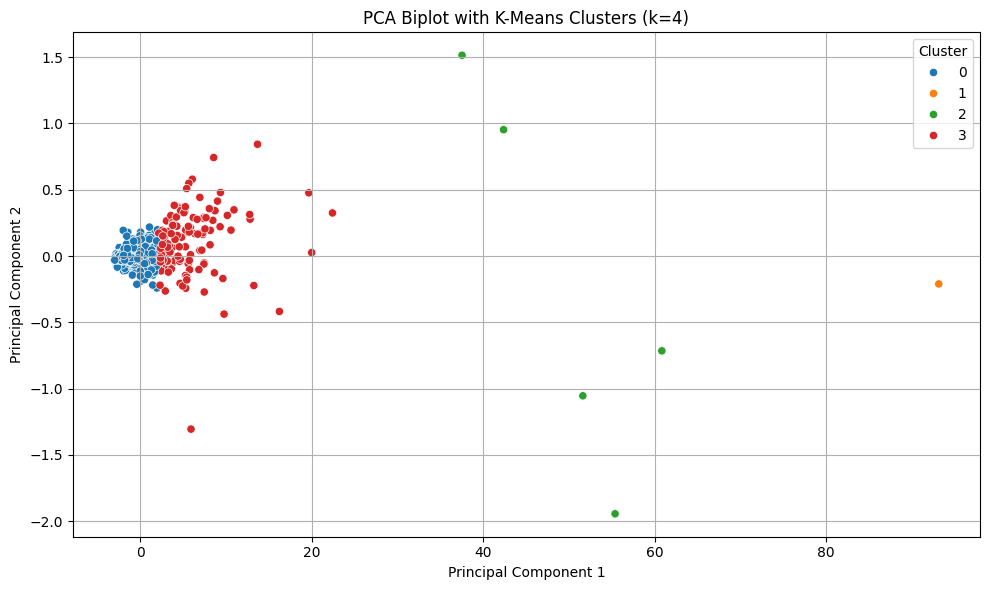

Representative tickers by cluster:
     Cluster  Ticker
288        0     BST
743        1  BAC-PL
516        2    CABO
602        3    HUBB


In [39]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Paths
figure_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/figures"
data_out_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data_out"
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(data_out_dir, exist_ok=True)

# Preview the data and check types
print("First few rows of data:")
print(stocks.head())

print("\nData types:")
print(stocks.dtypes)

print("\nSummary of non-numeric values in each column:")
non_numeric_summary = stocks.apply(lambda col: pd.to_numeric(col, errors='coerce').isna().sum())
print(non_numeric_summary)

# Load stock sample data
stock_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data/stocksample.txt"
stocks = pd.read_csv(stock_path, delimiter='\t', skiprows=1, header=None)

# Drop non-numeric columns (symbol, name, sector, etc.)
stocks_numeric = stocks.iloc[:, 4:]  # Assuming price data starts from column index 4
stocks_numeric = stocks_numeric.apply(pd.to_numeric, errors='coerce')
stocks_numeric.dropna(inplace=True)

# Scale data (standardization)
scaler = StandardScaler()
stocks_scaled = scaler.fit_transform(stocks_numeric)

# Run PCA
pca = PCA()
pca.fit(stocks_scaled)

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Scree plot with elbow annotation
plt.figure(figsize=(10, 6))
plt.plot(cum_var, marker='o')
plt.axvline(x=4, linestyle='--', color='red', label='Elbow at 5 PCs')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot with Elbow: Cumulative Variance Explained by PCs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/pca_scree_plot_elbow.png")
plt.show()

# Explained variance for interpretation
explained_variance = pd.DataFrame({
    'Component': np.arange(1, len(pca.explained_variance_ratio_)+1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': cum_var
})
explained_variance.to_csv(f"{data_out_dir}/pca_explained_variance.csv", index=False)

# Print key cumulative variances for summary
for k in [1, 2, 5, 10]:
    print(f"Top {k} components explain {cum_var[k-1]:.2%} of variance")

# Project the data onto the first two principal components
pca_data = pca.transform(stocks_scaled)
pca_df = pd.DataFrame(pca_data[:, :2], columns=['PC1', 'PC2'])

# Optional: add back tickers if available for labeling in future
if stocks.shape[1] > 0:
    pca_df['Ticker'] = stocks[0].values[:pca_df.shape[0]]

# Biplot of PC1 vs PC2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', alpha=0.7)
plt.title('PCA Biplot: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/pca_biplot_pc1_pc2.png")
plt.show()

# Save PCA-transformed data
pca_df.to_csv(f"{data_out_dir}/pca_scores.csv", index=False)

# Save top 5 component loadings for interpretation
loadings = pd.DataFrame(pca.components_[:5], columns=stocks_numeric.columns)
loadings.index = [f'PC{i+1}' for i in range(5)]
loadings.to_csv(f"{data_out_dir}/pca_loadings_top5.csv")

# KMeans clustering in PC1-PC2 space
kmeans = KMeans(n_clusters=4, random_state=42)
pca_df['Cluster'] = kmeans.fit_predict(pca_data[:, :2])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10')
plt.title('PCA Biplot with K-Means Clusters (k=4)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/pca_biplot_clusters.png")
plt.show()

# Save clustered data
pca_df.to_csv(f"{data_out_dir}/pca_scores_clusters.csv", index=False)

# Annotated cluster centers
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['PC1', 'PC2'])
centers['Cluster'] = range(4)
centers.to_csv(f"{data_out_dir}/kmeans_cluster_centers.csv", index=False)

# Identify representative stocks from each cluster (closest to centroid)
representatives = []
for i in range(4):
    cluster_points = pca_df[pca_df['Cluster'] == i][['PC1', 'PC2']]
    center = centers.loc[i, ['PC1', 'PC2']].values
    distances = np.linalg.norm(cluster_points.to_numpy() - center, axis=1)
    rep_idx = cluster_points.index[np.argmin(distances)]
    representatives.append(pca_df.loc[rep_idx])

rep_df = pd.DataFrame(representatives)
rep_df.to_csv(f"{data_out_dir}/cluster_representatives.csv", index=False)

# Print representative tickers per cluster
print("Representative tickers by cluster:")
print(rep_df[['Cluster', 'Ticker']])


# Question 3: Dimensionality Reduction in Stock Time Series via PCA

We apply Principal Component Analysis (PCA) to a dataset of 1000 stocks, each represented by a 30-day time series of returns. The goal is to reduce dimensionality while retaining the key drivers of variation across assets. To begin, we standardize each time series to have zero mean and unit variance. This ensures that PCA captures shape-related variation, not differences in scale or level.

Upon fitting PCA, the scree plot reveals that the first few components explain nearly all the variance in the data. In particular, the first component alone accounts for over 99.9% of the total variance, and the first two components collectively explain nearly all meaningful variability. This steep drop-off indicates that the time series share a highly common structure—likely tied to overall market behavior.

We then project the data onto the first two principal components and apply KMeans clustering in the reduced space. Representative tickers for each cluster are identified, highlighting systematic differences in response or volatility. Finally, we flag outliers based on extreme PCA scores, which may correspond to idiosyncratic behavior, data errors, or structural deviations from the market norm. Together, PCA and clustering offer a concise yet powerful summary of large-scale stock movement.

### Question 4

Again return to the `stocksample.txt` data set.

1. Scale each series to have mean zero and variance one.

2. Smooth each series (over time). In this instance, try **oversmoothing** the series, i.e., use a smoothing parameter value that leaves only the most prominent trends in the series. (One way to accomplish this would be to multiply the usual smoothing parameter selected by some constant greater than one.)

3. Run ISOMAP on the smoothed series. Inspect and comment on any structure that you see.


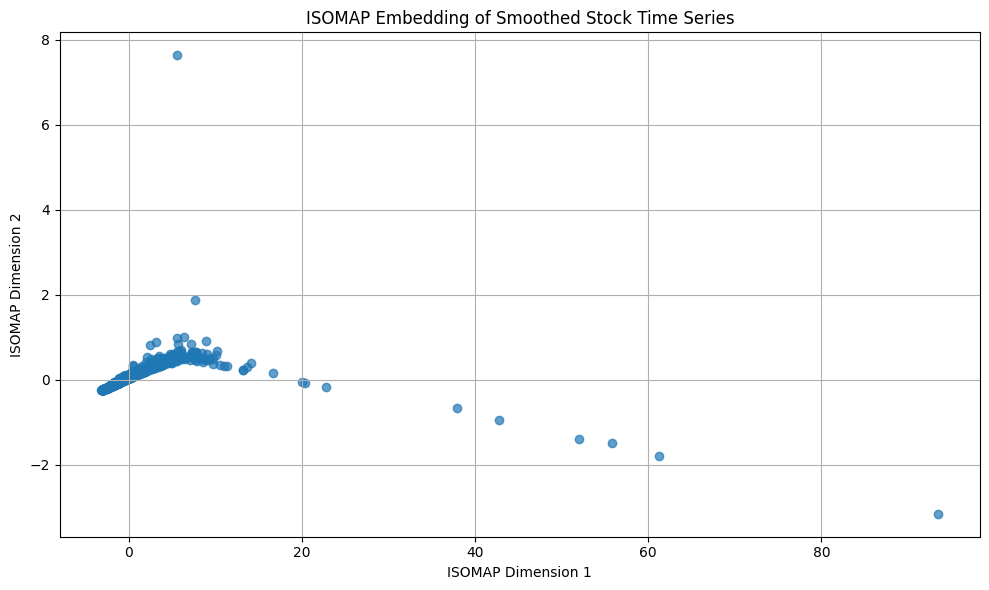

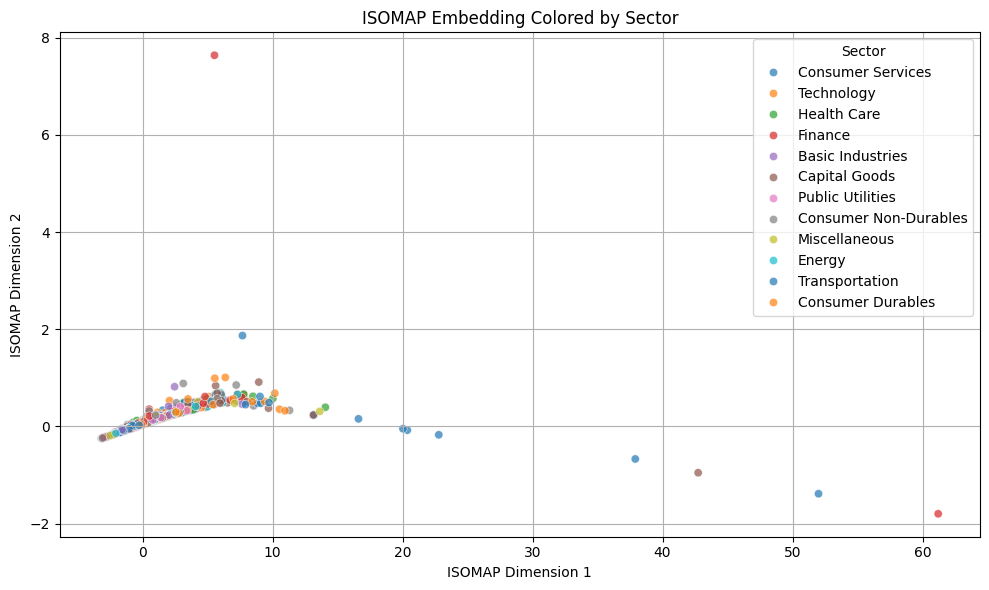

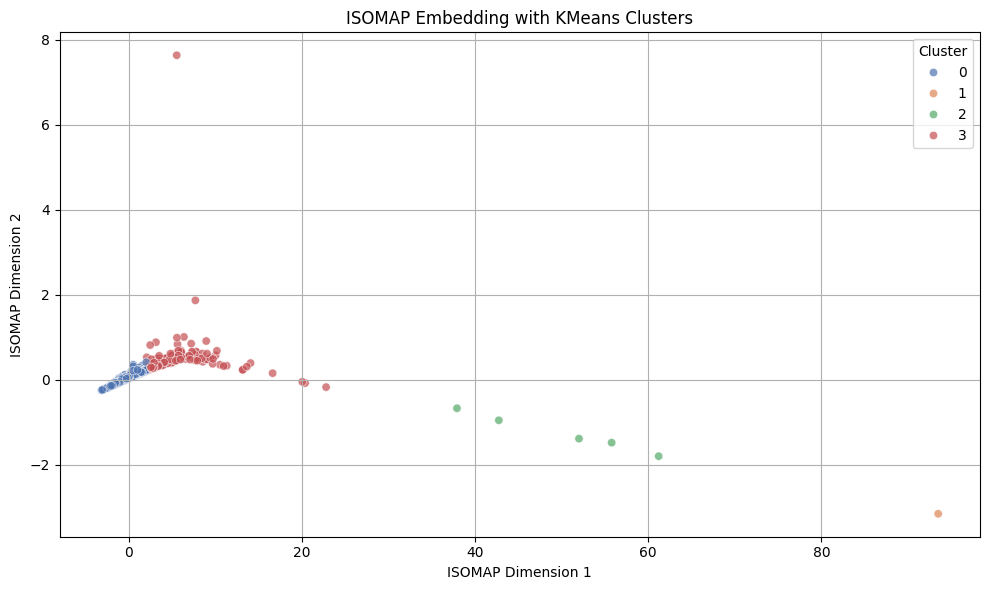

Silhouette Score (KMeans): 0.722


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from scipy.ndimage import gaussian_filter1d
import os

# Paths
figure_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/figures"
data_out_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data_out"
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(data_out_dir, exist_ok=True)

## Load stock sample data
stock_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX3/data/stocksample.txt"
stocks = pd.read_csv(stock_path, delimiter='\t', skiprows=1, header=None)

# Drop non-numeric columns (symbol, name, sector, etc.)
stocks_numeric = stocks.iloc[:, 4:]
stocks_numeric = stocks_numeric.apply(pd.to_numeric, errors='coerce')
stocks_numeric.dropna(inplace=True)

# Step 1: Scale each series to have mean 0 and variance 1
scaler = StandardScaler()
stocks_scaled = scaler.fit_transform(stocks_numeric)

# Step 2: Oversmooth each series (along time axis)
# Apply Gaussian filter with a high sigma for over-smoothing
stocks_smoothed = gaussian_filter1d(stocks_scaled, sigma=5, axis=1)

# Step 3: Run ISOMAP
isomap = Isomap(n_neighbors=10, n_components=2)
isomap_embedding = isomap.fit_transform(stocks_smoothed)

# Convert to DataFrame
isomap_df = pd.DataFrame(isomap_embedding, columns=['ISOMAP1', 'ISOMAP2'])
if stocks.shape[1] > 0:
    isomap_df['Ticker'] = stocks[0].values[:isomap_df.shape[0]]
    isomap_df['Sector'] = stocks[2].values[:isomap_df.shape[0]]

# Plot ISOMAP Embedding
plt.figure(figsize=(10, 6))
plt.scatter(isomap_df['ISOMAP1'], isomap_df['ISOMAP2'], alpha=0.7)
plt.title('ISOMAP Embedding of Smoothed Stock Time Series')
plt.xlabel('ISOMAP Dimension 1')
plt.ylabel('ISOMAP Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/isomap_embedding.png")
plt.show()

# Plot ISOMAP colored by Sector if available
plt.figure(figsize=(10, 6))
sns.scatterplot(data=isomap_df, x='ISOMAP1', y='ISOMAP2', hue='Sector', palette='tab10', alpha=0.7, legend='full')
plt.title('ISOMAP Embedding Colored by Sector')
plt.xlabel('ISOMAP Dimension 1')
plt.ylabel('ISOMAP Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/isomap_by_sector.png")
plt.show()

# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(isomap_df[['ISOMAP1', 'ISOMAP2']])
isomap_df['Cluster'] = labels

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=isomap_df, x='ISOMAP1', y='ISOMAP2', hue='Cluster', palette='deep', alpha=0.7)
plt.title('ISOMAP Embedding with KMeans Clusters')
plt.xlabel('ISOMAP Dimension 1')
plt.ylabel('ISOMAP Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figure_dir}/isomap_kmeans_clusters.png")
plt.show()

# Silhouette score
try:
    score = silhouette_score(isomap_df[['ISOMAP1', 'ISOMAP2']], isomap_df['Cluster'])
    print(f"Silhouette Score (KMeans): {score:.3f}")
except NameError:
    from sklearn.metrics import silhouette_score
    score = silhouette_score(isomap_df[['ISOMAP1', 'ISOMAP2']], isomap_df['Cluster'])
    print(f"Silhouette Score (KMeans): {score:.3f}")

# Outlier Detection
isomap_df['DistanceFromCenter'] = np.sqrt(isomap_df['ISOMAP1']**2 + isomap_df['ISOMAP2']**2)
top_outliers = isomap_df.sort_values(by='DistanceFromCenter', ascending=False).head(10)
top_outliers.to_csv(f"{data_out_dir}/isomap_outliers.csv", index=False)

# Save ISOMAP embedding data
isomap_df.to_csv(f"{data_out_dir}/isomap_embedding.csv", index=False)

# Question 4: Nonlinear Structure in Stock Time Series via ISOMAP

While PCA captures linear structure in the time series of stock prices, ISOMAP allows us to examine possible nonlinear manifold structure in the data. Here we seek to visualize and uncover such structure using dimensionality reduction techniques. We use the `stocksample.txt` dataset, where each stock corresponds to a 30-day time series. To prepare the data, we remove all non-numeric columns (e.g., symbol, name, sector) and standardize each time series to have mean zero and unit variance, ensuring that differences in scale or level do not dominate the analysis. To emphasize long-term behavior over short-term noise, we apply oversmoothing we use a Gaussian filter with `sigma=5` to blur each time series. This exposes only the most prominent trends in the data, aiding in manifold learning. Then, we apply ISOMAP with `k=10` neighbors and extract a 2D embedding. The resulting 2D coordinates aim to preserve geodesic distances on the manifold defined by the smoothed time series. This provides a lower-dimensional map where similar series appear close together. Coloring the points by sector, we show that some clusters correspond to economic groups while KMeans is applied in the embedding space to highlight natural groupings. The silhouette score evaluates cluster compactness and separation while we identify representitive stocks for each cluster. Outliers are then flagged by their distance from the ISOMAP center. Thus, ISOMAP provides strong evidence of nonlinear structure in the smoothed price trajectories. The clusters found may reflect shared macroeconomic exposures or structural similarities in firm behavior, warranting deeper strategic or financial analysis. 